In [1]:
import numpy as np
from modrem_utils import *
import matplotlib.pyplot as plt

In [2]:
mem_params = {"vec_len": 10,
              "num_loc_items": 54,
              "num_categories": 3,
              "categories": ["face", "scene", "fruit"],
              "loc_layers": ["visual", "verbal"],
              "main_layers": ["visual", "verbal"],
              "ic_ratio": 1,
              "em_ratio": 10,
              "num_loc_repeats": 5,
              "beta": 0.65,
              "trial_reset": True,
              "post_tau_style": "exp",    # ["exp", "power", "linear"]
              "post_tau": 8,
              "mem_source": "combined",
              "snr": 5,
              "init_state": "noise",
              "update_rules": {},
              }

In [3]:
# Initiate the experiment object
Exp = Modrem_Exp(mem_params)

In [4]:
#  Initiate localizer memories
loc_memories = Exp.create_loc_memories()

In [5]:
# The localizer memories are saved inside the Memories object attached to the Exp object
print(Exp.memories.loc_memories.shape)

(270, 2, 10)


In [5]:
clf = Exp.classifier_train()

Accuracy of classifier was 1.0. Training classifier on all loc


In [13]:
self = Exp
self.get_clf_layer_inds()

# First initiate a CV object
test_fold = [n for n in range(self.params["num_loc_repeats"]) for i in range(self.params["num_loc_items"])]
cv = PredefinedSplit(test_fold)
total_loc_items = self.params["num_loc_items"] * self.params["num_loc_repeats"]


In [16]:
X = self.memories.loc_memories[:, self.get_clf_layer_inds()].reshape(total_loc_items, -1)
y = self.label_encoder.transform(self.memories.loc_labels)
self.clf = OneVsRestClassifier(LogisticRegression(penalty="l2", solver="liblinear", C=1)).fit(X, y)
clf = self.clf
t, t_step = next(enumerate(self.current_trial))
t_step[self.get_clf_layer_inds()].reshape(-1).shape

Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17
item for step is scene_17
Incoming image is scene_17


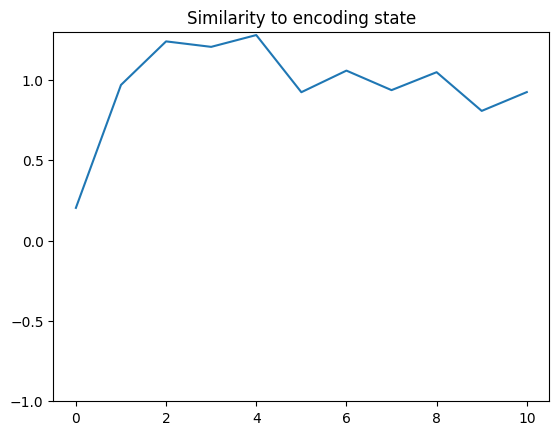

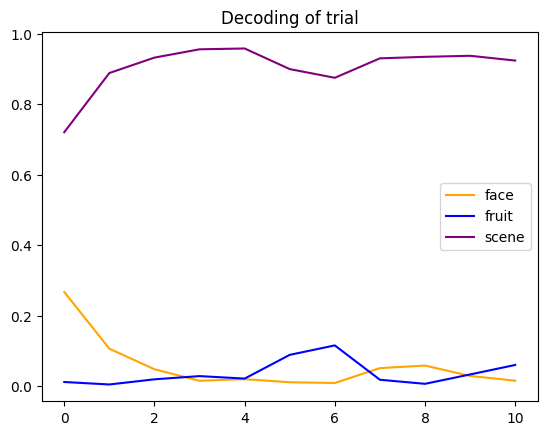

In [14]:
# Simulate 10 steps of encoding
Exp.reset_task_memories()
Exp.reset_current_trial()
current_trial = []
for n in range(10):
    current_trial.append(Exp.simulate_step(phase="encode",
                                           encode_category="scene"))
    # print(Exp.incoming_state)
# print(Exp.current_trial[1:] == current_trial)


x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial).reshape(len(Exp.current_trial), -1), Exp.encoding_representation.reshape(-1))
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

Exp.plot_current_trial()

item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
item for step is None
True


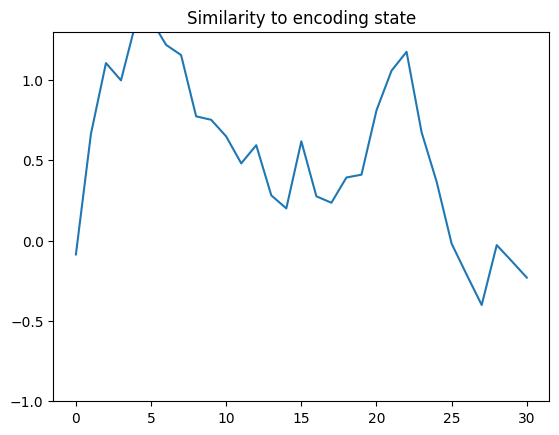

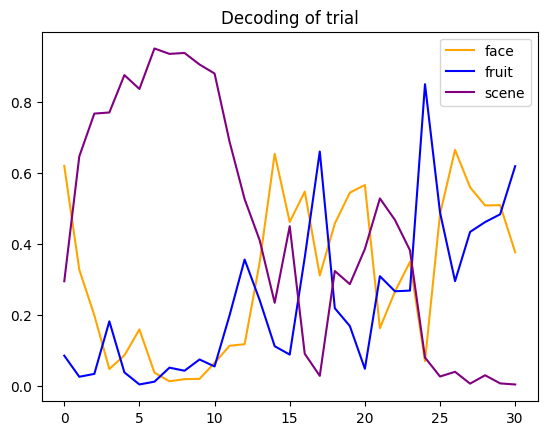

In [8]:
# Simulate 10 steps of maintain
maintain_portion = []
for n in range(10):
    current_trial.append(Exp.simulate_step(phase="maintain",
                                           encode_category="scene"))
    # print(Exp.incoming_state)
print(Exp.current_trial[1:] == current_trial)


x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial).reshape(len(Exp.current_trial), -1), Exp.encoding_representation.reshape(-1))
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

Exp.plot_current_trial()

In [9]:
# self = Exp.update_mechanism
# memstack = self.get_memstack()
# spec = self.update_rules["maintain"]
# memory_spec = spec["memory"]
# probe_layers = memory_spec["echo_layers"]
# probe = Exp.current_state
# similarity = np.zeros((len(memstack)))
# probe_layers = [probe_layers] if type(probe_layers) is not list else probe_layers
# probe = probe[np.newaxis, :] if probe.ndim == 1 else probe
# for i, probe_vector in enumerate(probe):
#             similarity[i, :] = np.dot(memstack[:, i], probe_vector)
# print(similarity)

Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item for step is fruit_3
Incoming image is fruit_3
item 

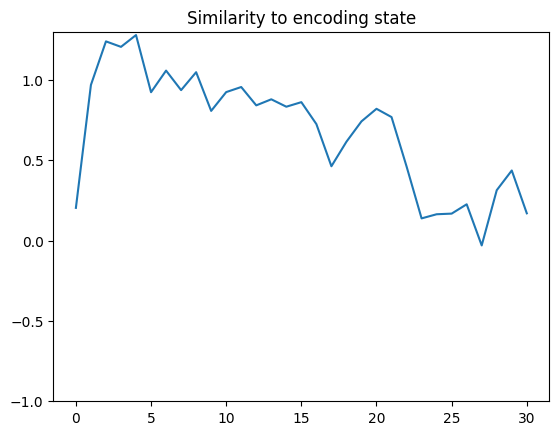

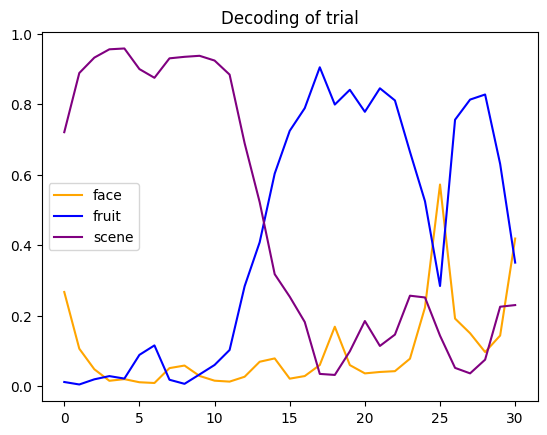

In [15]:
# Simulate 10 steps of replace
maintain_portion = []
for n in range(10):
    current_trial.append(Exp.simulate_step(phase="replace",
                                           replace_category="fruit"))
    # print(Exp.incoming_state)
print(Exp.current_trial[1:] == current_trial)


x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial).reshape(len(Exp.current_trial), -1), Exp.encoding_representation.reshape(-1))
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

Exp.plot_current_trial()

In [11]:
# # Simulate the encoding phase
# Exp.reset_task_memories()
# Exp.reset_current_trial()
# current_trial = []
# for n in range(10):
#     current_trial.append(Exp.simulate_encoding_timestep(category="scene"))
#     # print(Exp.incoming_state)
# print(Exp.current_trial[1:] == current_trial)
#
# x = np.arange(len(Exp.current_trial))
# y = np.dot(np.asarray(Exp.current_trial)[:, 0], Exp.encoding_state[0])
# plt.ylim(-1, 1.3)
# plt.plot(x, y)
# plt.title("Similarity to encoding state")
# plt.show()
#
# Exp.plot_current_trial()


In [12]:
# Simulate replace timesteps
for n in range(10):
    Exp.simulate_replace_timestep(category="fruit")


x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial).reshape(len(Exp.current_trial), -1), Exp.encoding_representation.reshape(-1))
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

# Also graph trial decoding
Exp.plot_current_trial()

AttributeError: 'Modrem_Exp' object has no attribute 'simulate_replace_timestep'

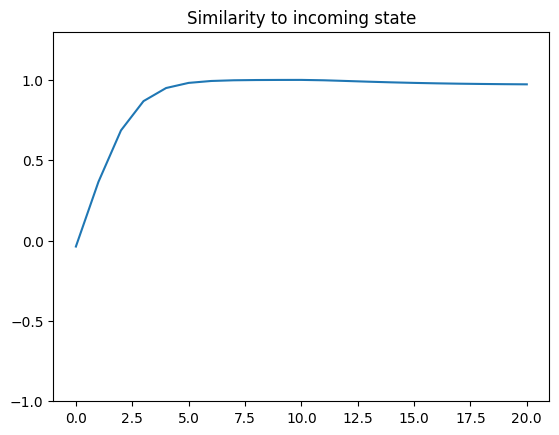

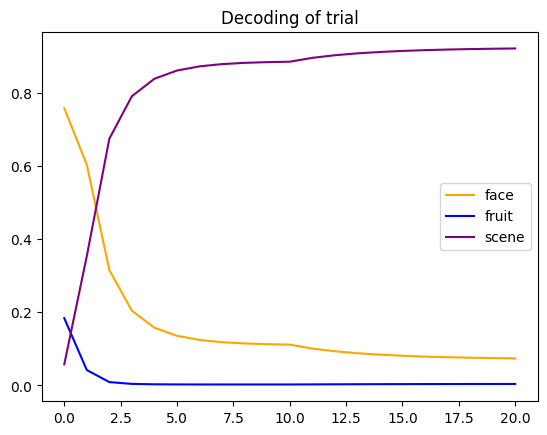

In [13]:
for n in range(10):
    Exp.simulate_maintain_timestep(variant="retrieval", source="combined")

x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial)[:, 0], Exp.encoding_state[0])
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to incoming state")
plt.show()

# Also graph trial decoding
Exp.plot_current_trial()

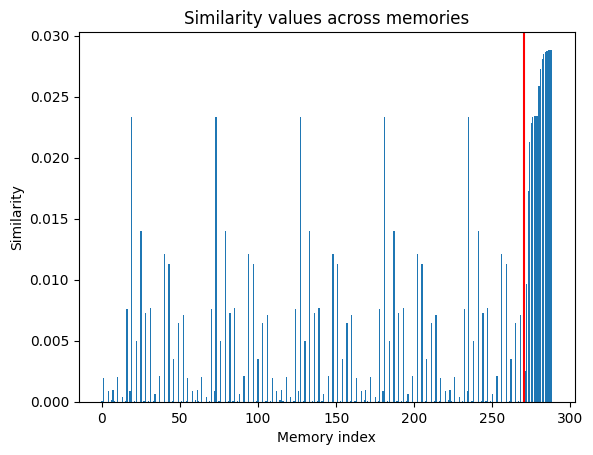

In [14]:
Exp.plot_current_similarity()

incoming state = current_state + external input + memory input

encoding = current_state + external input

maintenance = current_state + memory input


new_contextual_state (encoding condition) = current_contextual_state + external input + memory input

new_encoding_state = current_state + external input ("visual": face, "verbal": noise) + memory input (not implemented)

new_maintenance_state = current_state + external_input ("visual": noise, "verbal": noise) + memory_input

new_replace_state = current_state + external_input ("visual": noise, "verbal": scene) + memory_input